<a href="https://colab.research.google.com/github/abhishekhkumarsharma/Assignment_Solutions.ipynb/blob/main/Project%3A%20Predictive%20Analysis%20with%20Machine%20Learning%20Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project: Predictive Analysis with Machine Learning Models

- Worked on basic machine learning models for predictive analysis

In [1]:
import pandas as pd

# Load the California Housing Training dataset
df_housing = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Display the first 5 rows of the DataFrame
display(df_housing.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


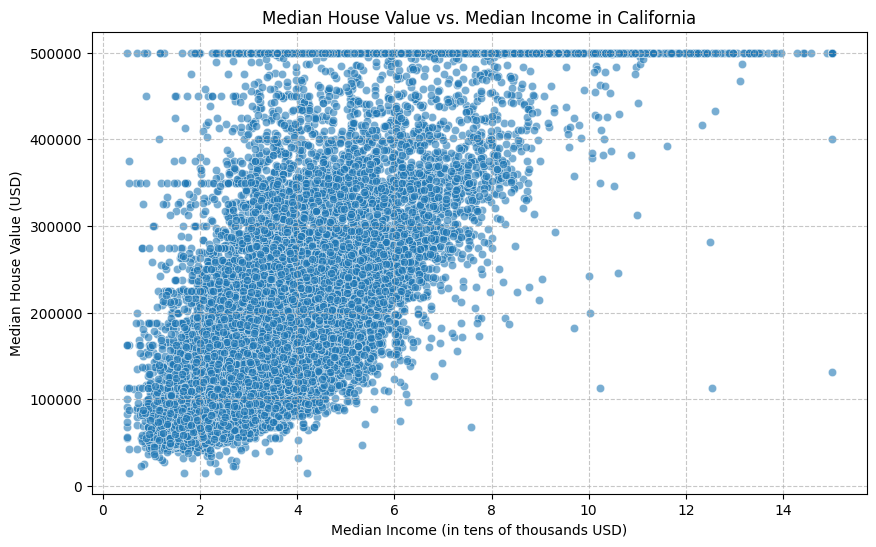

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_housing, x='median_income', y='median_house_value', alpha=0.6)
plt.title('Median House Value vs. Median Income in California')
plt.xlabel('Median Income (in tens of thousands USD)')
plt.ylabel('Median House Value (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Training a Linear Regression Model

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
X = df_housing.drop('median_house_value', axis=1)
y = df_housing['median_house_value']

# Handle any potential NaN values by dropping rows (for simplicity in this demo)
X = X.dropna()
y = y[X.index] # Ensure y matches the filtered X

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (13600, 8)
Test set shape: (3400, 8)


In [4]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [6]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display some actual vs predicted values
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(results_df.head())

Mean Squared Error (MSE): 4634658406.22
Root Mean Squared Error (RMSE): 68078.33
R-squared (R2): 0.66


,Actual,Predicted
10941,142700.0,143770.395030
5250,500001.0,398615.570565
10292,61800.0,86341.103067
2266,162800.0,148534.353533
6398,90600.0,147202.298086


### Feature Importance Analysis

In [7]:
# Get feature importances (coefficients for Linear Regression)
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

# Sort by absolute importance to see the most influential features
feature_importances['Absolute Importance'] = np.abs(feature_importances['Importance'])
feature_importances = feature_importances.sort_values(by='Absolute Importance', ascending=False)

display(feature_importances)

,Feature,Importance,Absolute Importance
0,longitude,-43465.247687,43465.247687
1,latitude,-43106.304441,43106.304441
7,median_income,40194.726347,40194.726347
2,housing_median_age,1131.724382,1131.724382
4,total_bedrooms,113.707973,113.707973
6,households,45.147555,45.147555
5,population,-35.657077,35.657077
3,total_rooms,-8.843261,8.843261


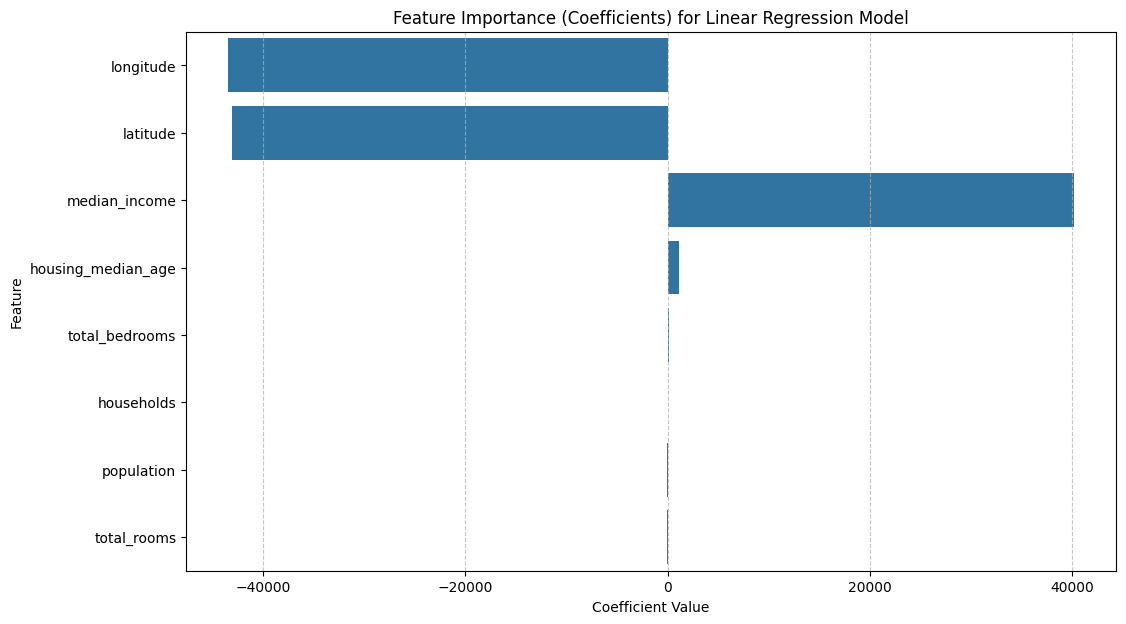

In [8]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance (Coefficients) for Linear Regression Model')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Project Summary for CV

### Predictive Analysis with Machine Learning Models - California Housing Prices

This project involved developing and evaluating a linear regression model to predict `median_house_value` using the California Housing dataset. Key steps and results are summarized below:

**1. Data Preparation & Exploration:**
*   Loaded `california_housing_train.csv` into a pandas DataFrame (`df_housing`).
*   Explored the relationship between `median_income` and `median_house_value` through a scatter plot, revealing a positive correlation.

**2. Model Training (Linear Regression):**
*   Data was split into 80% training (13,600 samples) and 20% testing (3,400 samples).
*   A `LinearRegression` model from `sklearn` was initialized and trained on the features to predict `median_house_value`.

**3. Model Evaluation:**
*   **Mean Squared Error (MSE):** `4.63 Billion`
*   **Root Mean Squared Error (RMSE):** `$68,078`
*   **R-squared (R2):** `0.66` (The model explains approximately 66% of the variance in median house values).

**4. Feature Importance Analysis:**
*   The most influential features, based on the absolute values of their regression coefficients, were identified as:
    *   `longitude`
    *   `latitude`
    *   `median_income`

This project demonstrates proficiency in data loading, exploratory data analysis, machine learning model development (linear regression), model evaluation, and interpretation of feature importance.